# [Project (3)- Association Rule Data Mining](#0)



## Introduction <a id="1"></a>
<p>I will examine association rule mining and sequential patterns mining, two unsupervised knowledge discovery strategies, in this project. Specifically, I will use the priori method to analyze a few real-world data sets from a financial firm's marketing department..</p>

**<p>In this project, I will utilize the dataset 'bank-data.csv'.</p>**


## Project Goals

The goal is to perform Association Rule discovery on the dataset using:

- The Apriori algorithm.
- The Frequent-Pattern Growth algorithm (FP-growth algorithm).
/p>

# Import and Reading Data

In [2]:
# Import necessary libraries

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import association_rules

plt.style.use('ggplot')
pd.set_option('display.max_columns', None) 

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the data into dataframe
data = pd.read_csv('bank-data.csv')

# Display the first 5 rows of the dataset
data.head(5)

,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48,FEMALE,INNER_CITY,17546.0,NO,1,NO,NO,NO,NO,YES
1,ID12102,40,MALE,TOWN,30085.1,YES,3,YES,NO,YES,YES,NO
2,ID12103,51,FEMALE,INNER_CITY,16575.4,YES,0,YES,YES,YES,NO,NO
3,ID12104,23,FEMALE,TOWN,20375.4,YES,3,NO,NO,YES,NO,NO
4,ID12105,57,FEMALE,RURAL,50576.3,YES,0,NO,YES,NO,NO,NO


### Data columns<a id="53"></a>

In [4]:
# Disply the name of columns in the Dataframe
data.columns

Index(['id', 'age', 'sex', 'region', 'income', 'married', 'children', 'car',
       'save_act', 'current_act', 'mortgage', 'pep'],
      dtype='object')

In [5]:
data.describe()

,age,income,children
count,800.000000,800.000000,800.000000
mean,42.238750,27334.769725,1.036250
std,14.407679,12769.258242,1.074187
min,18.000000,5014.210000,0.000000
25%,30.000000,17245.925000,0.000000
50%,42.000000,24762.050000,1.000000
75%,54.250000,36172.675000,2.000000
max,67.000000,63130.100000,3.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    object 
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   region       800 non-null    object 
 4   income       800 non-null    float64
 5   married      800 non-null    object 
 6   children     800 non-null    int64  
 7   car          800 non-null    object 
 8   save_act     800 non-null    object 
 9   current_act  800 non-null    object 
 10  mortgage     800 non-null    object 
 11  pep          800 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 75.1+ KB


#### No missing values

In [7]:
# To check if there is any duplicated data.
if not data.duplicated().any():
    print('No duplicated data')
else:
    print('Duplicated data found')


No duplicated data


# Data Preprocessing

In [8]:
# Remove 'id' field
data = data.drop(columns=['id'])


In [9]:
data.sample(5)

,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
316,60,MALE,INNER_CITY,22110.1,NO,2,YES,YES,YES,NO,NO
508,60,MALE,SUBURBAN,50409.9,NO,2,NO,YES,YES,YES,YES
142,28,FEMALE,TOWN,17240.6,YES,1,YES,NO,NO,YES,NO
535,29,MALE,INNER_CITY,10072.6,YES,0,NO,NO,YES,NO,NO
704,31,FEMALE,INNER_CITY,16678.0,YES,3,YES,NO,YES,YES,NO


## Mapping Data labels to more understandable form

In [10]:
# Map children labels
children_labels = {0: 'No_Child', 1: 'One_Child', 2: 'Two_Children', 3: 'Three_Children'}
data['children'] = data['children'].map(children_labels)

# Map married labels
married_labels = {"YES": 'YES_Married', "NO": 'No_Married'}
data['married'] = data['married'].map(married_labels)

# Map car labels
car_labels = {"YES": 'YES_Car', "NO": 'No_Car'}
data['car'] = data['car'].map(car_labels)

# Map save_act labels
save_act_labels = {"YES": 'YES_Save_act', "NO": 'No_Save_act'}
data['save_act'] = data['save_act'].map(save_act_labels)

# Map current_act labels
current_act_labels = {"YES": 'YES_Current_act', "NO": 'No_Current_act'}
data['current_act'] = data['current_act'].map(current_act_labels)

# Map mortgage labels
mortgage_labels = {"YES": 'YES_Mortgage', "NO": 'No_Mortgage'}
data['mortgage'] = data['mortgage'].map(mortgage_labels)

# Map pep labels
pep_labels = {"YES": 'YES_Pep', "NO": 'No_Pep'}
data['pep'] = data['pep'].map(pep_labels)

In [11]:
data.children.value_counts()

children
No_Child          348
Two_Children      179
One_Child         174
Three_Children     99
Name: count, dtype: int64

In [12]:
# Discretize 'age' and 'income'
age_labels = {
    (0, 18): 'Child',
    (19, 30): 'Young',
    (31, 50): 'Adult',
    (51, 100): 'Senior'
}

# Apply custom age labels
data['age'] = pd.cut(data['age'], bins=[0, 18, 30, 50, 100], labels=[label for _, label in age_labels.items()], include_lowest=True)
data['income'] = pd.qcut(data['income'], q=3, labels=['Low', 'Medium', 'High'])

In [13]:
data

,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,Adult,FEMALE,INNER_CITY,Low,No_Married,One_Child,No_Car,No_Save_act,No_Current_act,No_Mortgage,YES_Pep
1,Adult,MALE,TOWN,Medium,YES_Married,Three_Children,YES_Car,No_Save_act,YES_Current_act,YES_Mortgage,No_Pep
2,Senior,FEMALE,INNER_CITY,Low,YES_Married,No_Child,YES_Car,YES_Save_act,YES_Current_act,No_Mortgage,No_Pep
3,Young,FEMALE,TOWN,Medium,YES_Married,Three_Children,No_Car,No_Save_act,YES_Current_act,No_Mortgage,No_Pep
4,Senior,FEMALE,RURAL,High,YES_Married,No_Child,No_Car,YES_Save_act,No_Current_act,No_Mortgage,No_Pep
...,...,...,...,...,...,...,...,...,...,...,...
795,Senior,MALE,INNER_CITY,High,No_Married,One_Child,YES_Car,YES_Save_act,YES_Current_act,YES_Mortgage,No_Pep
796,Young,MALE,INNER_CITY,Low,No_Married,Two_Children,YES_Car,YES_Save_act,No_Current_act,No_Mortgage,No_Pep
797,Senior,MALE,RURAL,Medium,No_Married,No_Child,No_Car,No_Save_act,YES_Current_act,YES_Mortgage,YES_Pep
798,Adult,FEMALE,TOWN,Medium,YES_Married,No_Child,YES_Car,YES_Save_act,YES_Current_act,No_Mortgage,No_Pep


In [14]:
# Convert all elements in the DataFrame to strings
data = data.astype(str)

In [15]:
# Convert the DataFrame to a list of transactions
transactions = data.values.tolist()

In [16]:
# Convert the list of transactions to a one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

# Convert boolean values to integers (0/1)
encoded_df = encoded_df.astype(int)
encoded_df.head(5)

,Adult,Child,FEMALE,High,INNER_CITY,Low,MALE,Medium,No_Car,No_Child,No_Current_act,No_Married,No_Mortgage,No_Pep,No_Save_act,One_Child,RURAL,SUBURBAN,Senior,TOWN,Three_Children,Two_Children,YES_Car,YES_Current_act,YES_Married,YES_Mortgage,YES_Pep,YES_Save_act,Young
0,1,0,1,0,1,1,0,0,1,0,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,1,1,0,1,1,1,1,0,0,0
2,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,0,0,1,0
3,0,0,1,0,0,0,0,1,1,0,0,0,1,1,1,0,0,0,0,1,1,0,0,1,1,0,0,0,1
4,0,0,1,1,0,0,0,0,1,1,1,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0


#  Apply Apriori algorithm

In [17]:
# Apriori Frequent Itemsets
frequent_itemsets_apriori = apriori(encoded_df, min_support=0.25, use_colnames=True, verbose=1)

# Display the results
print('-'*60)
print(f"Number of Frequent Itemsets (Apriori): {len(frequent_itemsets_apriori)}")
print('-'*60)
print("Frequent Itemsets (Apriori):")
frequent_itemsets_apriori.sample(5)

Processing 36 combinations | Sampling itemset size 43
------------------------------------------------------------
Number of Frequent Itemsets (Apriori): 91
------------------------------------------------------------
Frequent Itemsets (Apriori):


,support,itemsets
51,0.29000,"(No_Child, No_Pep)"
74,0.26625,"(YES_Save_act, YES_Pep)"
90,0.34125,"(YES_Current_act, YES_Save_act, YES_Married)"
7,0.49375,(No_Car)
21,0.26000,"(No_Mortgage, Adult)"


In [18]:
# Apriori Rules
rules_apriori = association_rules(frequent_itemsets_apriori, metric='confidence', min_threshold=0.6)

# Display the results
print(f"Number of generated rules: {len(rules_apriori)}")
print('-'*60)
print("Rules (Apriori):")
rules_apriori.sample(5)

Number of generated rules: 98
------------------------------------------------------------
Rules (Apriori):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
40,(YES_Save_act),(No_Mortgage),0.68500,0.64125,0.44250,0.645985,1.007385,0.003244,1.013376,0.023271
83,"(YES_Save_act, YES_Married)",(No_Mortgage),0.45125,0.64125,0.29250,0.648199,1.010837,0.003136,1.019754,0.019537
96,"(YES_Current_act, YES_Married)",(YES_Save_act),0.47500,0.68500,0.34125,0.718421,1.048790,0.015875,1.118692,0.088610
67,"(No_Car, YES_Current_act)",(YES_Save_act),0.38125,0.68500,0.26125,0.685246,1.000359,0.000094,1.000781,0.000580
44,(YES_Save_act),(No_Pep),0.68500,0.59500,0.41875,0.611314,1.027418,0.011175,1.041972,0.084719


In [28]:
# Display the top 10 popular items for Apriori algorithm
top_items_apriori = frequent_itemsets_apriori.sort_values(by='support', ascending=False).head(10)
print("\nTop 10 Popular Items (Apriori):")
top_items_apriori


Top 10 Popular Items (Apriori):


,support,itemsets
16,0.75250,(YES_Current_act)
20,0.68500,(YES_Save_act)
17,0.64250,(YES_Married)
10,0.64125,(No_Mortgage)
11,0.59500,(No_Pep)
72,0.52500,"(YES_Current_act, YES_Save_act)"
1,0.50750,(FEMALE)
15,0.50625,(YES_Car)
7,0.49375,(No_Car)
5,0.49250,(MALE)


#  Apply FP-Growth algorithm

In [20]:
# FP-Growth Frequent Itemsets
frequent_itemsets_fpgrowth = fpgrowth(encoded_df, min_support=0.25, use_colnames=True)

# Display the results
print('-'*60)
print(f"Number of Frequent Itemsets (FP-Growth): {len(frequent_itemsets_fpgrowth)}")
print('-'*60)
print("Frequent Itemsets (FP-Growth):")
frequent_itemsets_fpgrowth.sample(5)



------------------------------------------------------------
Number of Frequent Itemsets (FP-Growth): 91
------------------------------------------------------------
Frequent Itemsets (FP-Growth):


,support,itemsets
13,0.4925,(MALE)
46,0.2600,"(No_Mortgage, Adult)"
63,0.3050,"(YES_Current_act, No_Pep, YES_Married)"
83,0.5250,"(YES_Current_act, YES_Save_act)"
33,0.2625,"(YES_Current_act, YES_Save_act, FEMALE)"


In [21]:
# FP-Growth Rules
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric='confidence', min_threshold=0.6)

# Display the results
print(f"Number of generated rules: {len(rules_fpgrowth)}")
print('-'*60)
print("Rules (FP-Growth):")
rules_fpgrowth.sample(5)

Number of generated rules: 98
------------------------------------------------------------
Rules (FP-Growth):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
20,"(No_Mortgage, FEMALE)",(YES_Current_act),0.33625,0.75250,0.26125,0.776952,1.032494,0.008222,1.109625,0.047414
27,(No_Car),(No_Pep),0.49375,0.59500,0.30375,0.615190,1.033933,0.009969,1.052467,0.064828
94,(No_Child),(No_Pep),0.43500,0.59500,0.29000,0.666667,1.120448,0.031175,1.215000,0.190265
72,"(No_Mortgage, YES_Married)",(No_Pep),0.40750,0.59500,0.27250,0.668712,1.123885,0.030038,1.222500,0.186041
79,(YES_Car),(No_Mortgage),0.50625,0.64125,0.33000,0.651852,1.016533,0.005367,1.030452,0.032940


In [29]:
# Display the top 10 popular items for FP-Growth algorithm
top_items_fpgrowth = frequent_itemsets_fpgrowth.sort_values(by='support', ascending=False).head(10)
print("\nTop 10 Popular Items (FP-Growth):")
top_items_fpgrowth


Top 10 Popular Items (FP-Growth):


,support,itemsets
9,0.75250,(YES_Current_act)
17,0.68500,(YES_Save_act)
10,0.64250,(YES_Married)
0,0.64125,(No_Mortgage)
11,0.59500,(No_Pep)
83,0.52500,"(YES_Current_act, YES_Save_act)"
1,0.50750,(FEMALE)
12,0.50625,(YES_Car)
2,0.49375,(No_Car)
21,0.49250,"(No_Mortgage, YES_Current_act)"


# Plotting

In [30]:
# Function to display bar plot
def plot_top_items(itemsets, algorithm_name):
    plt.figure(figsize=(10, 6))
    sns.barplot(x='support', y='itemsets', data=itemsets.head(10))
    plt.title(f'Top 10 Popular Items ({algorithm_name})')
    plt.xlabel('Support')
    plt.ylabel('Itemsets')
    plt.show()

# Function to display scatter plot
def plot_scatter(rules, algorithm_name):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='support', y='confidence', data=rules)
    plt.title(f'Scatter Plot of Rules ({algorithm_name})')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.show()

# Function to display rules and select top 5 interesting rules
def display_and_select_rules(rules, algorithm_name):
    print(f"\nTop 5 Interesting Rules ({algorithm_name}):\n")
    # Sort rules by lift, confidence, and support
    rules = rules.sort_values(by=['lift', 'confidence', 'support'], ascending=[False, False, False])
    interesting_rules = rules.head(5)
    print(interesting_rules)

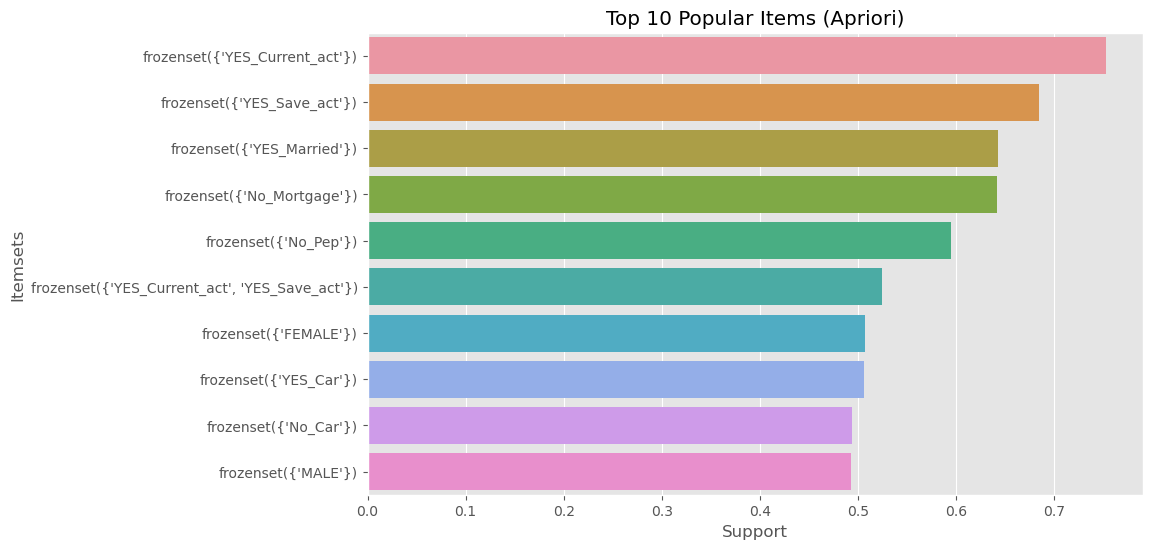

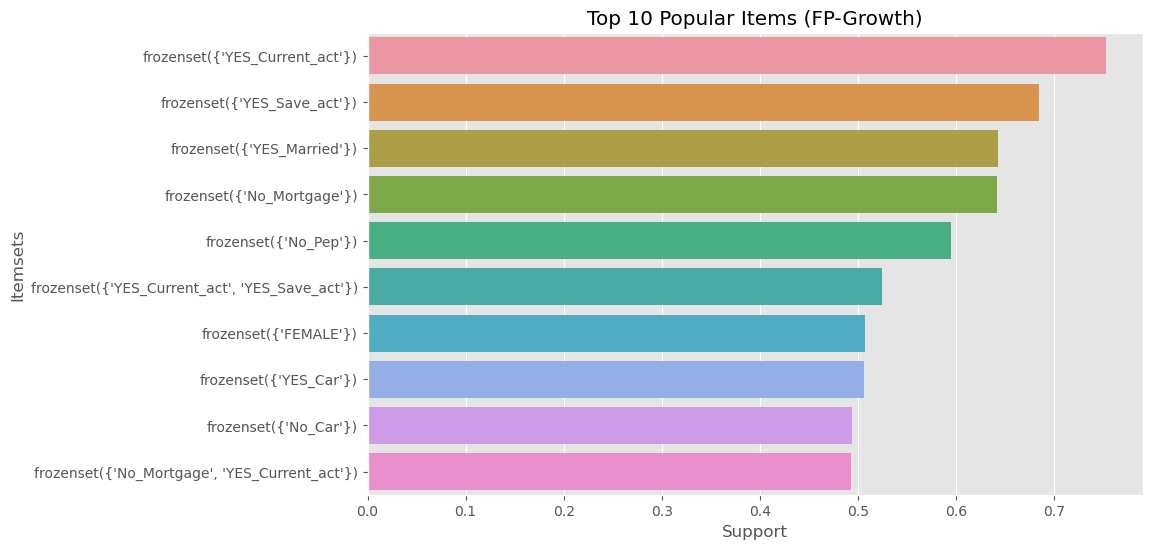

In [31]:
# Display and plot top items for each algorithm
plot_top_items(top_items_apriori, 'Apriori')
plot_top_items(top_items_fpgrowth, 'FP-Growth')

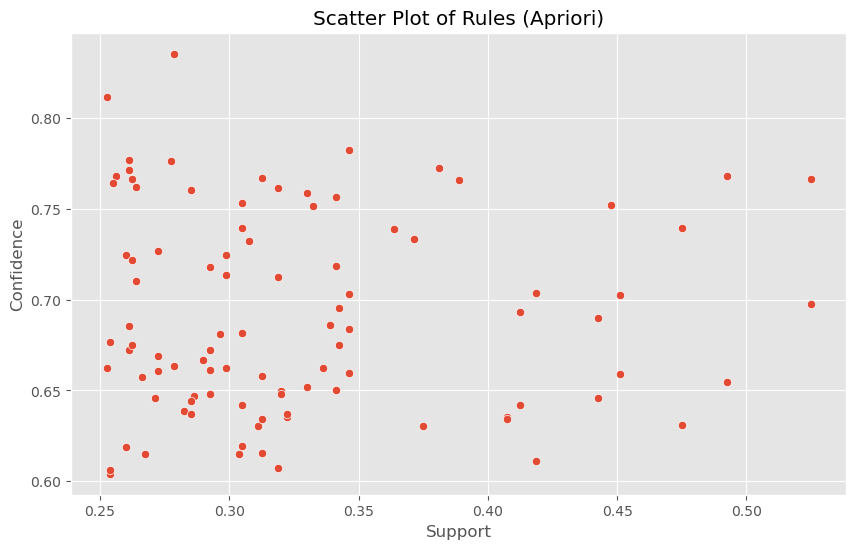

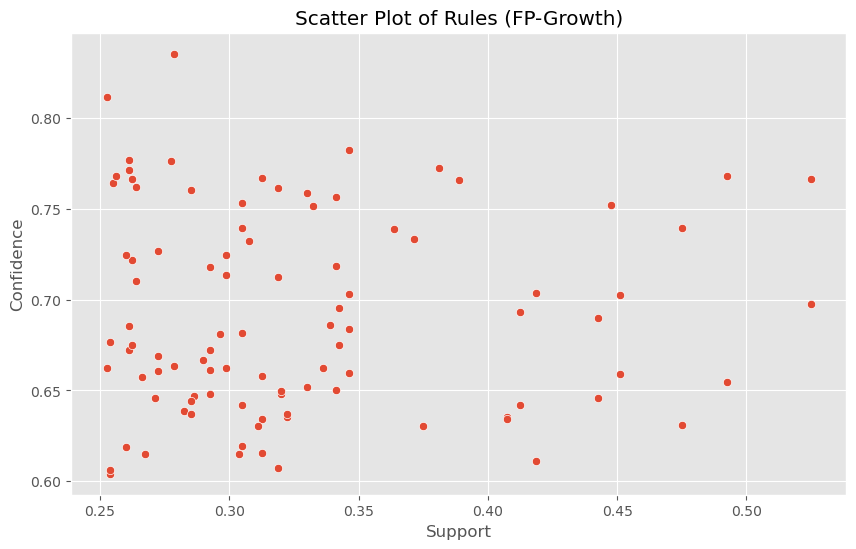

In [32]:
# Display and plot scatter plots for each algorithm
plot_scatter(rules_apriori, 'Apriori')
plot_scatter(rules_fpgrowth, 'FP-Growth')

In [33]:
# Display and select top 5 interesting rules for each algorithm
display_and_select_rules(rules_apriori, 'Apriori')
display_and_select_rules(rules_fpgrowth, 'FP-Growth')


Top 5 Interesting Rules (Apriori):

                    antecedents     consequents  antecedent support  \
11                       (High)  (YES_Save_act)             0.33375   
70        (No_Mortgage, No_Pep)   (YES_Married)             0.37500   
71   (No_Mortgage, YES_Married)        (No_Pep)             0.40750   
27                   (No_Child)        (No_Pep)             0.43500   
91  (YES_Save_act, YES_Married)        (No_Pep)             0.45125   

    consequent support  support  confidence      lift  leverage  conviction  \
11              0.6850  0.27875    0.835206  1.219279  0.050131    1.911477   
70              0.6425  0.27250    0.726667  1.130999  0.031563    1.307927   
71              0.5950  0.27250    0.668712  1.123885  0.030038    1.222500   
27              0.5950  0.29000    0.666667  1.120448  0.031175    1.215000   
91              0.5950  0.29875    0.662050  1.112689  0.030256    1.198402   

    zhangs_metric  
11       0.269933  
70       0.185321  
7

## Apriori Algorithm:

#### Rule 1: (High) -> (YES_Save_act)
**Explanation:** 83.5% of customers with high income also have a savings account. This pattern is interesting because it suggests a strong association between customers with high income and having a savings account.


**Recommendation:** The company might consider tailoring marketing strategies for high-income individuals to promote or enhance savings account services.

#### Rule 2: (No_Pep, No_Mortgage) -> (YES_Married)
**Explanation:** 72.7% of customers without a personal equity plan (PEP) and mortgage are married. This pattern indicates a connection between marital status and not having specific financial products.

**Recommendation:** The company could explore targeted marketing campaigns for married individuals who do not currently have a PEP or mortgage, potentially offering them tailored financial solutions.


#### Rule 3: (YES_Married, No_Mortgage) -> (No_Pep)
**Explanation:** 66.9% of married customers without a mortgage do not have a personal equity plan (PEP). This implies that married individuals without a mortgage are less likely to invest in PEPs.

**Recommendation:** The company might want to focus on understanding the investment preferences of married customers without mortgages and develop suitable investment options or educational content.

#### Rule 4: (No_Child) -> (No_Pep)
**Explanation:**  66.7% of customers without children do not have a personal equity plan (PEP). This indicates a potential correlation between not having children and a lower likelihood of investing in PEPs.

**Recommendation:** The company could target marketing efforts towards customers without children, emphasizing investment opportunities or financial planning.

#### Rule 5: (YES_Married, YES_Save_act) -> (No_Pep)
**Explanation:**  66.2% of married customers with a savings account do not have a personal equity plan (PEP). This pattern suggests that having a savings account among married individuals may not necessarily translate into having a PEP.

**Recommendation:** The company may consider exploring the reasons behind this association and tailor marketing strategies to promote PEPs among married individuals with savings accounts.

# Top 5 Interesting Rules (FP-Growth):
The explanations and recommendations for the top 5 rules in FP-Growth are the same as those for Apriori because the rules and their metrics are identical for both algorithms in this case
.

### Summary & Conclusion
In summary, these rules provide insights into associations between various customer characteristics and financial behaviors. The company can use these insights to refine its marketing strategies, target specific customer segments, and potentially offer personalized financial products or services based on observed patterns.